<a href="https://colab.research.google.com/github/DeepanshuSharma1607/ipl-winner-pedictor/blob/main/ipl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1326]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [1327]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "IPL_ball_by_ball_updated.csv"

# Load the latest version
df_nn = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "dgsports/ipl-ball-by-ball-2008-to-2022",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

# print("First 5 records:", df__.head())

/tmp/ipykernel_1706/1014396691.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df_nn = kagglehub.load_dataset(


Using Colab cache for faster access to the 'ipl-ball-by-ball-2008-to-2022' dataset.


In [1328]:
print(df_nn.head(10))

   match_id  season  start_date                  venue  innings  ball  \
0    335982    2008  2008-04-18  M Chinnaswamy Stadium        1   0.1   
1    335982    2008  2008-04-18  M Chinnaswamy Stadium        1   0.2   
2    335982    2008  2008-04-18  M Chinnaswamy Stadium        1   0.3   
3    335982    2008  2008-04-18  M Chinnaswamy Stadium        1   0.4   
4    335982    2008  2008-04-18  M Chinnaswamy Stadium        1   0.5   
5    335982    2008  2008-04-18  M Chinnaswamy Stadium        1   0.6   
6    335982    2008  2008-04-18  M Chinnaswamy Stadium        1   0.7   
7    335982    2008  2008-04-18  M Chinnaswamy Stadium        1   1.1   
8    335982    2008  2008-04-18  M Chinnaswamy Stadium        1   1.2   
9    335982    2008  2008-04-18  M Chinnaswamy Stadium        1   1.3   

            batting_team                 bowling_team      striker  \
0  Kolkata Knight Riders  Royal Challengers Bangalore   SC Ganguly   
1  Kolkata Knight Riders  Royal Challengers Bangalore  B

In [1329]:
# df_matches.shape

In [1330]:
df_nn.columns

Index(['match_id', 'season', 'start_date', 'venue', 'innings', 'ball',
       'batting_team', 'bowling_team', 'striker', 'non_striker', 'bowler',
       'runs_off_bat', 'extras', 'wides', 'noballs', 'byes', 'legbyes',
       'penalty', 'wicket_type', 'player_dismissed', 'other_wicket_type',
       'other_player_dismissed'],
      dtype='object')

In [1331]:
df_nn.shape

(243815, 22)

In [1332]:
df_nn.isnull().sum()

,0
match_id,0
season,0
start_date,0
venue,0
innings,0
ball,0
batting_team,0
bowling_team,0
striker,0
non_striker,0


In [1333]:
df_nn

,match_id,season,start_date,venue,innings,ball,batting_team,bowling_team,striker,non_striker,...,extras,wides,noballs,byes,legbyes,penalty,wicket_type,player_dismissed,other_wicket_type,other_player_dismissed
0,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.1,Kolkata Knight Riders,Royal Challengers Bangalore,SC Ganguly,BB McCullum,...,1,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
1,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.2,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.3,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,...,1,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.4,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.5,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
243810,1370353,2023,2023-05-29,"Narendra Modi Stadium, Ahmedabad",2,14.2,Chennai Super Kings,Gujarat Titans,S Dube,RA Jadeja,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
243811,1370353,2023,2023-05-29,"Narendra Modi Stadium, Ahmedabad",2,14.3,Chennai Super Kings,Gujarat Titans,RA Jadeja,S Dube,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
243812,1370353,2023,2023-05-29,"Narendra Modi Stadium, Ahmedabad",2,14.4,Chennai Super Kings,Gujarat Titans,S Dube,RA Jadeja,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
243813,1370353,2023,2023-05-29,"Narendra Modi Stadium, Ahmedabad",2,14.5,Chennai Super Kings,Gujarat Titans,RA Jadeja,S Dube,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [1334]:

df=df_nn.copy()

In [1335]:
team_mapping = {
    # Rebranded Teams
    'Delhi Daredevils': 'Delhi Capitals',
    'Kings XI Punjab': 'Punjab Kings',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru',

    # Successor Franchises (Optional but recommended for model logic)
    'Deccan Chargers': 'Sunrisers Hyderabad',
    'Rising Pune Supergiants': 'Rising Pune Supergiant',
    'Pune Warriors': 'Rising Pune Supergiant'
}

# Apply to both team columns
df['batting_team'] = df['batting_team'].replace(team_mapping)
df['bowling_team'] = df['bowling_team'].replace(team_mapping)


In [1336]:
df

,match_id,season,start_date,venue,innings,ball,batting_team,bowling_team,striker,non_striker,...,extras,wides,noballs,byes,legbyes,penalty,wicket_type,player_dismissed,other_wicket_type,other_player_dismissed
0,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.1,Kolkata Knight Riders,Royal Challengers Bengaluru,SC Ganguly,BB McCullum,...,1,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
1,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.2,Kolkata Knight Riders,Royal Challengers Bengaluru,BB McCullum,SC Ganguly,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.3,Kolkata Knight Riders,Royal Challengers Bengaluru,BB McCullum,SC Ganguly,...,1,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.4,Kolkata Knight Riders,Royal Challengers Bengaluru,BB McCullum,SC Ganguly,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.5,Kolkata Knight Riders,Royal Challengers Bengaluru,BB McCullum,SC Ganguly,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
243810,1370353,2023,2023-05-29,"Narendra Modi Stadium, Ahmedabad",2,14.2,Chennai Super Kings,Gujarat Titans,S Dube,RA Jadeja,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
243811,1370353,2023,2023-05-29,"Narendra Modi Stadium, Ahmedabad",2,14.3,Chennai Super Kings,Gujarat Titans,RA Jadeja,S Dube,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
243812,1370353,2023,2023-05-29,"Narendra Modi Stadium, Ahmedabad",2,14.4,Chennai Super Kings,Gujarat Titans,S Dube,RA Jadeja,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
243813,1370353,2023,2023-05-29,"Narendra Modi Stadium, Ahmedabad",2,14.5,Chennai Super Kings,Gujarat Titans,RA Jadeja,S Dube,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [1337]:
df.shape

(243815, 22)

In [1338]:
df

,match_id,season,start_date,venue,innings,ball,batting_team,bowling_team,striker,non_striker,...,extras,wides,noballs,byes,legbyes,penalty,wicket_type,player_dismissed,other_wicket_type,other_player_dismissed
0,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.1,Kolkata Knight Riders,Royal Challengers Bengaluru,SC Ganguly,BB McCullum,...,1,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
1,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.2,Kolkata Knight Riders,Royal Challengers Bengaluru,BB McCullum,SC Ganguly,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.3,Kolkata Knight Riders,Royal Challengers Bengaluru,BB McCullum,SC Ganguly,...,1,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.4,Kolkata Knight Riders,Royal Challengers Bengaluru,BB McCullum,SC Ganguly,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.5,Kolkata Knight Riders,Royal Challengers Bengaluru,BB McCullum,SC Ganguly,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
243810,1370353,2023,2023-05-29,"Narendra Modi Stadium, Ahmedabad",2,14.2,Chennai Super Kings,Gujarat Titans,S Dube,RA Jadeja,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
243811,1370353,2023,2023-05-29,"Narendra Modi Stadium, Ahmedabad",2,14.3,Chennai Super Kings,Gujarat Titans,RA Jadeja,S Dube,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
243812,1370353,2023,2023-05-29,"Narendra Modi Stadium, Ahmedabad",2,14.4,Chennai Super Kings,Gujarat Titans,S Dube,RA Jadeja,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
243813,1370353,2023,2023-05-29,"Narendra Modi Stadium, Ahmedabad",2,14.5,Chennai Super Kings,Gujarat Titans,RA Jadeja,S Dube,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [1339]:
df.columns

Index(['match_id', 'season', 'start_date', 'venue', 'innings', 'ball',
       'batting_team', 'bowling_team', 'striker', 'non_striker', 'bowler',
       'runs_off_bat', 'extras', 'wides', 'noballs', 'byes', 'legbyes',
       'penalty', 'wicket_type', 'player_dismissed', 'other_wicket_type',
       'other_player_dismissed'],
      dtype='object')

In [1340]:
print(df[['runs_off_bat', 'extras', 'wides', 'noballs', 'byes', 'legbyes',
       'penalty', 'wicket_type', 'player_dismissed', 'other_wicket_type',
       'other_player_dismissed']])

        runs_off_bat  extras  wides  noballs  byes  legbyes  penalty  \
0                  0       1    NaN      NaN   NaN      1.0      NaN   
1                  0       0    NaN      NaN   NaN      NaN      NaN   
2                  0       1    1.0      NaN   NaN      NaN      NaN   
3                  0       0    NaN      NaN   NaN      NaN      NaN   
4                  0       0    NaN      NaN   NaN      NaN      NaN   
...              ...     ...    ...      ...   ...      ...      ...   
243810             1       0    NaN      NaN   NaN      NaN      NaN   
243811             1       0    NaN      NaN   NaN      NaN      NaN   
243812             1       0    NaN      NaN   NaN      NaN      NaN   
243813             6       0    NaN      NaN   NaN      NaN      NaN   
243814             4       0    NaN      NaN   NaN      NaN      NaN   

       wicket_type player_dismissed  other_wicket_type  other_player_dismissed  
0              NaN              NaN                NaN

In [1341]:
cols_to_fix = ['runs_off_bat', 'extras', 'wides', 'noballs', 'byes', 'legbyes', 'penalty']
df[cols_to_fix] = df[cols_to_fix].fillna(0)

df['curr_ball_runs'] = df['runs_off_bat'] + df['extras']
total_score = df.groupby(['match_id', 'innings', 'batting_team'])['curr_ball_runs'].cumsum().reset_index()


In [1342]:
df['team_runs'] = df.groupby(['match_id','batting_team'])['curr_ball_runs'].cumsum()
df['team_runs'] = df.groupby(['match_id','batting_team'])['team_runs'].shift(1).fillna(0)

In [1343]:
df['first_innings_runs'] = np.where(df['innings'] == 1, df['team_runs'], 0)

df['second_innings_runs'] = np.where(df['innings'] == 2, df['team_runs'], 0)

In [1344]:
df

,match_id,season,start_date,venue,innings,ball,batting_team,bowling_team,striker,non_striker,...,legbyes,penalty,wicket_type,player_dismissed,other_wicket_type,other_player_dismissed,curr_ball_runs,team_runs,first_innings_runs,second_innings_runs
0,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.1,Kolkata Knight Riders,Royal Challengers Bengaluru,SC Ganguly,BB McCullum,...,1.0,0.0,NaN,NaN,NaN,NaN,1,0.0,0.0,0.0
1,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.2,Kolkata Knight Riders,Royal Challengers Bengaluru,BB McCullum,SC Ganguly,...,0.0,0.0,NaN,NaN,NaN,NaN,0,1.0,1.0,0.0
2,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.3,Kolkata Knight Riders,Royal Challengers Bengaluru,BB McCullum,SC Ganguly,...,0.0,0.0,NaN,NaN,NaN,NaN,1,1.0,1.0,0.0
3,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.4,Kolkata Knight Riders,Royal Challengers Bengaluru,BB McCullum,SC Ganguly,...,0.0,0.0,NaN,NaN,NaN,NaN,0,2.0,2.0,0.0
4,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.5,Kolkata Knight Riders,Royal Challengers Bengaluru,BB McCullum,SC Ganguly,...,0.0,0.0,NaN,NaN,NaN,NaN,0,2.0,2.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
243810,1370353,2023,2023-05-29,"Narendra Modi Stadium, Ahmedabad",2,14.2,Chennai Super Kings,Gujarat Titans,S Dube,RA Jadeja,...,0.0,0.0,NaN,NaN,NaN,NaN,1,158.0,0.0,158.0
243811,1370353,2023,2023-05-29,"Narendra Modi Stadium, Ahmedabad",2,14.3,Chennai Super Kings,Gujarat Titans,RA Jadeja,S Dube,...,0.0,0.0,NaN,NaN,NaN,NaN,1,159.0,0.0,159.0
243812,1370353,2023,2023-05-29,"Narendra Modi Stadium, Ahmedabad",2,14.4,Chennai Super Kings,Gujarat Titans,S Dube,RA Jadeja,...,0.0,0.0,NaN,NaN,NaN,NaN,1,160.0,0.0,160.0
243813,1370353,2023,2023-05-29,"Narendra Modi Stadium, Ahmedabad",2,14.5,Chennai Super Kings,Gujarat Titans,RA Jadeja,S Dube,...,0.0,0.0,NaN,NaN,NaN,NaN,6,161.0,0.0,161.0


In [1345]:
df['is_wicket']=df['player_dismissed'].notna().astype(int)

In [1346]:
df.columns

Index(['match_id', 'season', 'start_date', 'venue', 'innings', 'ball',
       'batting_team', 'bowling_team', 'striker', 'non_striker', 'bowler',
       'runs_off_bat', 'extras', 'wides', 'noballs', 'byes', 'legbyes',
       'penalty', 'wicket_type', 'player_dismissed', 'other_wicket_type',
       'other_player_dismissed', 'curr_ball_runs', 'team_runs',
       'first_innings_runs', 'second_innings_runs', 'is_wicket'],
      dtype='object')

In [1347]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243815 entries, 0 to 243814
Data columns (total 27 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   match_id                243815 non-null  int64  
 1   season                  243815 non-null  int64  
 2   start_date              243815 non-null  object 
 3   venue                   243815 non-null  object 
 4   innings                 243815 non-null  int64  
 5   ball                    243815 non-null  float64
 6   batting_team            243815 non-null  object 
 7   bowling_team            243815 non-null  object 
 8   striker                 243815 non-null  object 
 9   non_striker             243815 non-null  object 
 10  bowler                  243815 non-null  object 
 11  runs_off_bat            243815 non-null  int64  
 12  extras                  243815 non-null  int64  
 13  wides                   243815 non-null  float64
 14  noballs             

In [1348]:
df

,match_id,season,start_date,venue,innings,ball,batting_team,bowling_team,striker,non_striker,...,penalty,wicket_type,player_dismissed,other_wicket_type,other_player_dismissed,curr_ball_runs,team_runs,first_innings_runs,second_innings_runs,is_wicket
0,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.1,Kolkata Knight Riders,Royal Challengers Bengaluru,SC Ganguly,BB McCullum,...,0.0,NaN,NaN,NaN,NaN,1,0.0,0.0,0.0,0
1,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.2,Kolkata Knight Riders,Royal Challengers Bengaluru,BB McCullum,SC Ganguly,...,0.0,NaN,NaN,NaN,NaN,0,1.0,1.0,0.0,0
2,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.3,Kolkata Knight Riders,Royal Challengers Bengaluru,BB McCullum,SC Ganguly,...,0.0,NaN,NaN,NaN,NaN,1,1.0,1.0,0.0,0
3,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.4,Kolkata Knight Riders,Royal Challengers Bengaluru,BB McCullum,SC Ganguly,...,0.0,NaN,NaN,NaN,NaN,0,2.0,2.0,0.0,0
4,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.5,Kolkata Knight Riders,Royal Challengers Bengaluru,BB McCullum,SC Ganguly,...,0.0,NaN,NaN,NaN,NaN,0,2.0,2.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
243810,1370353,2023,2023-05-29,"Narendra Modi Stadium, Ahmedabad",2,14.2,Chennai Super Kings,Gujarat Titans,S Dube,RA Jadeja,...,0.0,NaN,NaN,NaN,NaN,1,158.0,0.0,158.0,0
243811,1370353,2023,2023-05-29,"Narendra Modi Stadium, Ahmedabad",2,14.3,Chennai Super Kings,Gujarat Titans,RA Jadeja,S Dube,...,0.0,NaN,NaN,NaN,NaN,1,159.0,0.0,159.0,0
243812,1370353,2023,2023-05-29,"Narendra Modi Stadium, Ahmedabad",2,14.4,Chennai Super Kings,Gujarat Titans,S Dube,RA Jadeja,...,0.0,NaN,NaN,NaN,NaN,1,160.0,0.0,160.0,0
243813,1370353,2023,2023-05-29,"Narendra Modi Stadium, Ahmedabad",2,14.5,Chennai Super Kings,Gujarat Titans,RA Jadeja,S Dube,...,0.0,NaN,NaN,NaN,NaN,6,161.0,0.0,161.0,0


In [1349]:
final_scores = df[df['innings'] == 1].groupby('match_id')['team_runs'].max()
df = df.merge(final_scores.rename('target'), on='match_id')
df['target'] = np.where(df['innings'] == 2, df['target'] + 1, 0)

In [1350]:
df['over'] = df['ball'].astype(str).str.split('.').str[0].astype(int)
df['ball_in_over'] = df['ball'].astype(str).str.split('.').str[1].astype(int)

In [1351]:
df['ball_in_over'] = df['ball_in_over'].clip(upper=6)
df['balls_bowled'] = df['over'] * 6 + df['ball_in_over']

In [1352]:
df['runs_to_win'] = np.where(
    df['innings'] == 2,
    df['target'] - df['team_runs'],
    0
)

In [1353]:
df['runs_to_win'] = np.where(
    df['innings'] == 2,
    df['target'] - df['team_runs'],
    0
)

In [1354]:
balls_remaining = (120 - df['balls_bowled']).clip(lower=0)


In [1355]:
df['curr_run_rate'] = np.where(
    df['balls_bowled'] == 0, 0,
    (df['team_runs'] * 6) / df['balls_bowled']
)

In [1356]:
df['req_run_rate'] = np.where(
    balls_remaining == 0,
    np.inf,
    (df['runs_to_win'] * 6) / balls_remaining
)
df['req_run_rate'] = df['req_run_rate'].clip(0, 36)


In [1357]:
df['req_run_rate'] = df['req_run_rate'].replace(np.inf, 100)

In [1358]:
df['crr_rrr_ratio'] = df['curr_run_rate'] / df['req_run_rate'].replace(0, np.inf)

df['crr_rrr_ratio'] = df['crr_rrr_ratio'].clip(0, 10)

df.loc[df['innings'] == 1,
       ['target', 'runs_to_win', 'req_run_rate', 'crr_rrr_ratio']] = 0

In [1359]:
df['balls_remaining'] = (20 * 6) - df['balls_bowled']

In [1360]:
df['total_wickets'] = df.groupby(['match_id','innings'])['is_wicket'].cumsum()
df['total_wickets'] = df.groupby(['match_id','innings'])['total_wickets'].shift(1).fillna(0)
df['wickets_remaining'] = 10 - df['total_wickets']

In [1361]:
df

,match_id,season,start_date,venue,innings,ball,batting_team,bowling_team,striker,non_striker,...,over,ball_in_over,balls_bowled,runs_to_win,curr_run_rate,req_run_rate,crr_rrr_ratio,balls_remaining,total_wickets,wickets_remaining
0,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.1,Kolkata Knight Riders,Royal Challengers Bengaluru,SC Ganguly,BB McCullum,...,0,1,1,0.0,0.000000,0.000000,0.000000,119,0.0,10.0
1,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.2,Kolkata Knight Riders,Royal Challengers Bengaluru,BB McCullum,SC Ganguly,...,0,2,2,0.0,3.000000,0.000000,0.000000,118,0.0,10.0
2,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.3,Kolkata Knight Riders,Royal Challengers Bengaluru,BB McCullum,SC Ganguly,...,0,3,3,0.0,2.000000,0.000000,0.000000,117,0.0,10.0
3,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.4,Kolkata Knight Riders,Royal Challengers Bengaluru,BB McCullum,SC Ganguly,...,0,4,4,0.0,3.000000,0.000000,0.000000,116,0.0,10.0
4,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.5,Kolkata Knight Riders,Royal Challengers Bengaluru,BB McCullum,SC Ganguly,...,0,5,5,0.0,2.400000,0.000000,0.000000,115,0.0,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
243810,1370353,2023,2023-05-29,"Narendra Modi Stadium, Ahmedabad",2,14.2,Chennai Super Kings,Gujarat Titans,S Dube,RA Jadeja,...,14,2,86,57.0,11.023256,10.058824,1.095879,34,5.0,5.0
243811,1370353,2023,2023-05-29,"Narendra Modi Stadium, Ahmedabad",2,14.3,Chennai Super Kings,Gujarat Titans,RA Jadeja,S Dube,...,14,3,87,56.0,10.965517,10.181818,1.076970,33,5.0,5.0
243812,1370353,2023,2023-05-29,"Narendra Modi Stadium, Ahmedabad",2,14.4,Chennai Super Kings,Gujarat Titans,S Dube,RA Jadeja,...,14,4,88,55.0,10.909091,10.312500,1.057851,32,5.0,5.0
243813,1370353,2023,2023-05-29,"Narendra Modi Stadium, Ahmedabad",2,14.5,Chennai Super Kings,Gujarat Titans,RA Jadeja,S Dube,...,14,5,89,54.0,10.853933,10.451613,1.038494,31,5.0,5.0


In [1362]:
df.columns

Index(['match_id', 'season', 'start_date', 'venue', 'innings', 'ball',
       'batting_team', 'bowling_team', 'striker', 'non_striker', 'bowler',
       'runs_off_bat', 'extras', 'wides', 'noballs', 'byes', 'legbyes',
       'penalty', 'wicket_type', 'player_dismissed', 'other_wicket_type',
       'other_player_dismissed', 'curr_ball_runs', 'team_runs',
       'first_innings_runs', 'second_innings_runs', 'is_wicket', 'target',
       'over', 'ball_in_over', 'balls_bowled', 'runs_to_win', 'curr_run_rate',
       'req_run_rate', 'crr_rrr_ratio', 'balls_remaining', 'total_wickets',
       'wickets_remaining'],
      dtype='object')

In [1363]:
df['is_out'] = (df['player_dismissed'] == df['striker']).astype(int)

df['valid_ball'] = (df['wides'] == 0).astype(int)

# df['batsman_run_cum'] = df.groupby(['match_id','striker'])['runs_off_bat'].cumsum()
# df['batsman_run_cum'] = df.groupby(['match_id','striker'])['batsman_run_cum'].shift(1).fillna(0)

# df['balls_faced_cum'] = df.groupby(['match_id','striker'])['valid_ball'].cumsum()
# df['balls_faced_cum'] = df.groupby(['match_id','striker'])['balls_faced_cum'].shift(1).fillna(0)

# df['match_strike_rate'] = np.where(
#     df['balls_faced_cum'] == 0,
#     0,
#     (df['batsman_run_cum'] / df['balls_faced_cum']) * 100
# )



# df['batsman_run_cum_career'] = df.groupby('striker')['runs_off_bat'].cumsum()
# df['batsman_run_cum_career'] = df.groupby('striker')['batsman_run_cum_career'].shift(1).fillna(0)

# df['balls_faced_cum_career'] = df.groupby('striker')['valid_ball'].cumsum()
# df['balls_faced_cum_career'] = df.groupby('striker')['balls_faced_cum_career'].shift(1).fillna(0)

# df['batsman_outs_career'] = df.groupby('striker')['is_out'].cumsum()
# df['batsman_outs_career'] = df.groupby('striker')['batsman_outs_career'].shift(1).fillna(0)

# universal_runs = 50
# universal_outs = 2

# df['batting_average'] = (
#     df['batsman_run_cum_career'] + universal_runs
# ) / (
#     df['batsman_outs_career'] + universal_outs
# )


# universal_sr_runs = 100
# universal_balls = 80

# df['career_strike_rate'] = (
#     (df['batsman_run_cum_career'] + universal_sr_runs) /
#     (df['balls_faced_cum_career'] + universal_balls)
# ) * 100
# Aggregate per striker per season
season_bat = df.groupby(['season', 'striker']).agg(
    season_runs=('runs_off_bat', 'sum'),
    season_balls=('valid_ball', 'sum'),
    season_outs=('is_out', 'sum')
).reset_index().sort_values(['striker', 'season'])

# Cumsum then shift — so current season stats NOT included
season_bat['career_runs'] = season_bat.groupby('striker')['season_runs'].cumsum().shift(1).fillna(0)
season_bat['career_balls'] = season_bat.groupby('striker')['season_balls'].cumsum().shift(1).fillna(0)
season_bat['career_outs'] = season_bat.groupby('striker')['season_outs'].cumsum().shift(1).fillna(0)

# Smoothed stats
season_bat['batting_average'] = (season_bat['career_runs'] + 50) / (season_bat['career_outs'] + 2)
season_bat['career_strike_rate'] = ((season_bat['career_runs'] + 100) / (season_bat['career_balls'] + 80)) * 100

# Merge back
df = df.merge(
    season_bat[['season', 'striker', 'batting_average', 'career_strike_rate']],
    on=['season', 'striker'], how='left'
)

In [1364]:


# df['bowler_runs_conceded'] = df.groupby('bowler')['runs_off_bat'].cumsum()
# df['bowler_runs_conceded'] = df.groupby('bowler')['bowler_runs_conceded'].shift(1).fillna(0)

# df['bowler_balls_bowled'] = df.groupby('bowler')['valid_ball'].cumsum()
# df['bowler_balls_bowled'] = df.groupby('bowler')['bowler_balls_bowled'].shift(1).fillna(0)

# df['bowler_wickets_cum'] = df.groupby('bowler')['is_wicket'].cumsum()
# df['bowler_wickets_cum'] = df.groupby('bowler')['bowler_wickets_cum'].shift(1).fillna(0)



# universal_runs_conceded = 300
# universal_balls = 240
# universal_wickets = 10


# df['exp_bowler_eco'] = (
#     (df['bowler_runs_conceded'] + universal_runs_conceded) /
#     (df['bowler_balls_bowled'] + universal_balls)
# ) * 6


# df['exp_bowler_avg'] = (
#     df['bowler_runs_conceded'] + universal_runs_conceded
# ) / (
#     df['bowler_wickets_cum'] + universal_wickets
# )
# Aggregate per bowler per season
season_bowl = df.groupby(['season', 'bowler']).agg(
    season_runs_c=('runs_off_bat', 'sum'),
    season_balls_b=('valid_ball', 'sum'),
    season_wkts=('is_wicket', 'sum')
).reset_index().sort_values(['bowler', 'season'])

# Cumsum then shift — so current season NOT included
season_bowl['career_runs_c'] = season_bowl.groupby('bowler')['season_runs_c'].cumsum().shift(1).fillna(0)
season_bowl['career_balls_b'] = season_bowl.groupby('bowler')['season_balls_b'].cumsum().shift(1).fillna(0)
season_bowl['career_wkts'] = season_bowl.groupby('bowler')['season_wkts'].cumsum().shift(1).fillna(0)

# Smoothed stats
season_bowl['exp_bowler_eco'] = ((season_bowl['career_runs_c'] + 300) / (season_bowl['career_balls_b'] + 240)) * 6
season_bowl['exp_bowler_avg'] = (season_bowl['career_runs_c'] + 300) / (season_bowl['career_wkts'] + 10)

# Merge back
df = df.merge(
    season_bowl[['season', 'bowler', 'exp_bowler_eco', 'exp_bowler_avg']],
    on=['season', 'bowler'], how='left'
)

In [1365]:
df.columns

Index(['match_id', 'season', 'start_date', 'venue', 'innings', 'ball',
       'batting_team', 'bowling_team', 'striker', 'non_striker', 'bowler',
       'runs_off_bat', 'extras', 'wides', 'noballs', 'byes', 'legbyes',
       'penalty', 'wicket_type', 'player_dismissed', 'other_wicket_type',
       'other_player_dismissed', 'curr_ball_runs', 'team_runs',
       'first_innings_runs', 'second_innings_runs', 'is_wicket', 'target',
       'over', 'ball_in_over', 'balls_bowled', 'runs_to_win', 'curr_run_rate',
       'req_run_rate', 'crr_rrr_ratio', 'balls_remaining', 'total_wickets',
       'wickets_remaining', 'is_out', 'valid_ball', 'batting_average',
       'career_strike_rate', 'exp_bowler_eco', 'exp_bowler_avg'],
      dtype='object')

In [1366]:
df.shape

(243815, 44)

In [1367]:
final_scores = df.groupby(['match_id', 'innings'])['team_runs'].max().reset_index()
final_scores = final_scores.pivot(index='match_id', columns='innings', values='team_runs').reset_index()
final_scores['winner_innings'] = np.where(
    final_scores[2] > final_scores[1], 2,
    np.where(final_scores[2] < final_scores[1], 1, 0)
)

df = df.merge(final_scores[['match_id', 'winner_innings']], on='match_id', how='left')

df['result'] = np.where(
    (df['innings'] == 2) & (df['winner_innings'] == 2),
    1,
    np.where(
        (df['innings'] == 2) & (df['winner_innings'] == 1),
        0,
        -1   # tie
    )
)

In [1368]:
df.shape

(243815, 46)

In [1369]:
df.columns

Index(['match_id', 'season', 'start_date', 'venue', 'innings', 'ball',
       'batting_team', 'bowling_team', 'striker', 'non_striker', 'bowler',
       'runs_off_bat', 'extras', 'wides', 'noballs', 'byes', 'legbyes',
       'penalty', 'wicket_type', 'player_dismissed', 'other_wicket_type',
       'other_player_dismissed', 'curr_ball_runs', 'team_runs',
       'first_innings_runs', 'second_innings_runs', 'is_wicket', 'target',
       'over', 'ball_in_over', 'balls_bowled', 'runs_to_win', 'curr_run_rate',
       'req_run_rate', 'crr_rrr_ratio', 'balls_remaining', 'total_wickets',
       'wickets_remaining', 'is_out', 'valid_ball', 'batting_average',
       'career_strike_rate', 'exp_bowler_eco', 'exp_bowler_avg',
       'winner_innings', 'result'],
      dtype='object')

In [1370]:
drop_list = [
    'match_id', 'start_date', 'runs_off_bat', 'extras', 'wides',
    'noballs', 'byes', 'legbyes', 'penalty', 'curr_ball_runs',
    'wicket_type', 'player_dismissed', 'other_wicket_type',
    'other_player_dismissed', 'is_wicket', 'is_out', 'winner_innings',
    'ball', 'over', 'ball_in_over', 'balls_bowled', 'valid_ball',
    'team_runs', 'first_innings_runs', 'second_innings_runs', 'target',
    # 'batsman_run_cum', 'balls_faced_cum',
    'total_wickets'
]
df = df.drop(columns=drop_list)

In [1371]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243815 entries, 0 to 243814
Data columns (total 19 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   season              243815 non-null  int64  
 1   venue               243815 non-null  object 
 2   innings             243815 non-null  int64  
 3   batting_team        243815 non-null  object 
 4   bowling_team        243815 non-null  object 
 5   striker             243815 non-null  object 
 6   non_striker         243815 non-null  object 
 7   bowler              243815 non-null  object 
 8   runs_to_win         243815 non-null  float64
 9   curr_run_rate       243815 non-null  float64
 10  req_run_rate        243815 non-null  float64
 11  crr_rrr_ratio       243815 non-null  float64
 12  balls_remaining     243815 non-null  int64  
 13  wickets_remaining   243815 non-null  float64
 14  batting_average     243815 non-null  float64
 15  career_strike_rate  243815 non-nul

In [1372]:
df

,season,venue,innings,batting_team,bowling_team,striker,non_striker,bowler,runs_to_win,curr_run_rate,req_run_rate,crr_rrr_ratio,balls_remaining,wickets_remaining,batting_average,career_strike_rate,exp_bowler_eco,exp_bowler_avg,result
0,2008,M Chinnaswamy Stadium,1,Kolkata Knight Riders,Royal Challengers Bengaluru,SC Ganguly,BB McCullum,P Kumar,0.0,0.000000,0.000000,0.000000,119,10.0,13.000000,122.891566,7.647059,35.454545,-1
1,2008,M Chinnaswamy Stadium,1,Kolkata Knight Riders,Royal Challengers Bengaluru,BB McCullum,SC Ganguly,P Kumar,0.0,3.000000,0.000000,0.000000,118,10.0,13.250000,119.767442,7.647059,35.454545,-1
2,2008,M Chinnaswamy Stadium,1,Kolkata Knight Riders,Royal Challengers Bengaluru,BB McCullum,SC Ganguly,P Kumar,0.0,2.000000,0.000000,0.000000,117,10.0,13.250000,119.767442,7.647059,35.454545,-1
3,2008,M Chinnaswamy Stadium,1,Kolkata Knight Riders,Royal Challengers Bengaluru,BB McCullum,SC Ganguly,P Kumar,0.0,3.000000,0.000000,0.000000,116,10.0,13.250000,119.767442,7.647059,35.454545,-1
4,2008,M Chinnaswamy Stadium,1,Kolkata Knight Riders,Royal Challengers Bengaluru,BB McCullum,SC Ganguly,P Kumar,0.0,2.400000,0.000000,0.000000,115,10.0,13.250000,119.767442,7.647059,35.454545,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
243810,2023,"Narendra Modi Stadium, Ahmedabad",2,Chennai Super Kings,Gujarat Titans,S Dube,RA Jadeja,MM Sharma,57.0,11.023256,10.058824,1.095879,34,5.0,25.448276,132.214765,8.184000,24.800000,0
243811,2023,"Narendra Modi Stadium, Ahmedabad",2,Chennai Super Kings,Gujarat Titans,RA Jadeja,S Dube,MM Sharma,56.0,10.965517,10.181818,1.076970,33,5.0,27.148936,127.549020,8.184000,24.800000,0
243812,2023,"Narendra Modi Stadium, Ahmedabad",2,Chennai Super Kings,Gujarat Titans,S Dube,RA Jadeja,MM Sharma,55.0,10.909091,10.312500,1.057851,32,5.0,25.448276,132.214765,8.184000,24.800000,0
243813,2023,"Narendra Modi Stadium, Ahmedabad",2,Chennai Super Kings,Gujarat Titans,RA Jadeja,S Dube,MM Sharma,54.0,10.853933,10.451613,1.038494,31,5.0,27.148936,127.549020,8.184000,24.800000,0


In [1373]:
df = df[df['innings'] <= 2]
df = df[df['result'] != -1]


In [1374]:
df.describe()

,season,innings,runs_to_win,curr_run_rate,req_run_rate,crr_rrr_ratio,balls_remaining,wickets_remaining,batting_average,career_strike_rate,exp_bowler_eco,exp_bowler_avg,result
count,103412.00000,103412.0,103412.000000,103412.000000,103412.000000,103412.000000,103412.000000,103412.000000,103412.000000,103412.000000,103412.000000,103412.000000,103412.000000
mean,2015.64450,2.0,94.912012,7.163956,10.373683,0.902514,62.609175,7.505657,27.764467,128.511521,7.524946,26.716769,0.274813
std,4.63419,0.0,50.219457,2.264983,5.882801,0.889135,33.544251,2.177735,8.477640,12.360424,0.506973,4.983105,0.446422
min,2008.00000,2.0,-15.000000,0.000000,0.000000,0.000000,0.000000,1.000000,5.428571,82.530120,5.914198,14.846154,0.000000
25%,2012.00000,2.0,55.000000,6.000000,7.451613,0.518094,34.000000,6.000000,22.000000,121.111111,7.238938,23.048780,0.000000
50%,2015.00000,2.0,94.000000,7.317073,9.148515,0.748971,63.000000,8.000000,27.879310,127.231565,7.567797,25.916667,0.000000
75%,2020.00000,2.0,133.000000,8.538462,11.361702,1.029595,92.000000,9.000000,32.788462,135.235732,7.860759,30.090909,1.000000
max,2023.00000,2.0,264.000000,24.000000,36.000000,10.000000,119.000000,10.000000,67.333333,180.335731,8.949153,44.571429,1.000000


In [1375]:
df = df[df['innings'] == 2]
df = df[df['runs_to_win'] >= 0]
df = df[df['balls_remaining'] > 0]

In [1376]:
df.describe()

,season,innings,runs_to_win,curr_run_rate,req_run_rate,crr_rrr_ratio,balls_remaining,wickets_remaining,batting_average,career_strike_rate,exp_bowler_eco,exp_bowler_avg,result
count,102579.000000,102579.0,102579.000000,102579.000000,102579.000000,102579.000000,102579.000000,102579.000000,102579.000000,102579.000000,102579.000000,102579.000000,102579.000000
mean,2015.643407,2.0,95.589048,7.155494,10.278940,0.908755,63.076858,7.532029,27.799327,128.539862,7.523958,26.715360,0.273370
std,4.634391,0.0,49.827068,2.269089,5.592451,0.889970,33.260688,2.156706,8.467761,12.353729,0.507339,4.983616,0.445691
min,2008.000000,2.0,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,5.428571,82.530120,5.914198,14.846154,0.000000
25%,2012.000000,2.0,56.000000,6.000000,7.462185,0.523824,35.000000,6.000000,22.074728,121.132540,7.233379,23.048780,0.000000
50%,2015.000000,2.0,95.000000,7.307692,9.142857,0.752874,64.000000,8.000000,28.000000,127.231565,7.567416,25.916667,0.000000
75%,2020.000000,2.0,133.000000,8.531250,11.320755,1.033104,92.000000,9.000000,32.788462,135.266084,7.858407,30.090909,1.000000
max,2023.000000,2.0,264.000000,24.000000,36.000000,10.000000,119.000000,10.000000,67.333333,180.335731,8.949153,44.571429,1.000000


In [1377]:
train = df[df['season'] <= 2020]        # 2008-2020 → 13 seasons
cv    = df[(df['season'] >= 2021) & (df['season'] <= 2022)]  # 2021-2022 → 2 seasons
test  = df[df['season'] == 2023]        # 2023 → 1 season

In [1378]:
x_train = train.drop('result', axis=1)
y_train = train['result']

x_cv = cv.drop('result', axis=1)
y_cv = cv['result']

x_test = test.drop('result', axis=1)
y_test = test['result']

In [1379]:
print("Train:", train['season'].unique())
print("CV:", cv['season'].unique())
print("Test:", test['season'].unique())

Train: [2008 2009 2010 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020]
CV: [2021 2022]
Test: [2023]


In [1380]:
x_train = x_train.drop(columns=['season'])
x_cv = x_cv.drop(columns=['season'])
x_test = x_test.drop(columns=['season'])

In [1381]:
# from sklearn.model_selection import train_test_split
# x_train,x_temp,y_train,y_temp=train_test_split(df, y, test_size=0.4, random_state=42)
# x_cv,x_test,y_cv,y_test=train_test_split(x_temp, y_temp,test_size=0.5, random_state=42)

In [1382]:
x_train = x_train.drop(columns=['innings'])
x_cv = x_cv.drop(columns=['innings'])
x_test = x_test.drop(columns=['innings'])

In [1383]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 81408 entries, 124 to 193615
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   venue               81408 non-null  object 
 1   batting_team        81408 non-null  object 
 2   bowling_team        81408 non-null  object 
 3   striker             81408 non-null  object 
 4   non_striker         81408 non-null  object 
 5   bowler              81408 non-null  object 
 6   runs_to_win         81408 non-null  float64
 7   curr_run_rate       81408 non-null  float64
 8   req_run_rate        81408 non-null  float64
 9   crr_rrr_ratio       81408 non-null  float64
 10  balls_remaining     81408 non-null  int64  
 11  wickets_remaining   81408 non-null  float64
 12  batting_average     81408 non-null  float64
 13  career_strike_rate  81408 non-null  float64
 14  exp_bowler_eco      81408 non-null  float64
 15  exp_bowler_avg      81408 non-null  float64
dtypes: flo

In [1384]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder,TargetEncoder,StandardScaler
from sklearn.linear_model import LogisticRegression
target_encode=['striker','bowler','non_striker']
nominal_cols=['batting_team','bowling_team','venue']
numeric_cols=['runs_to_win', 'curr_run_rate', 'req_run_rate', 'crr_rrr_ratio',
              'balls_remaining', 'wickets_remaining',
              #'match_strike_rate',
              'batting_average',
              'exp_bowler_eco', 'exp_bowler_avg']
print("Infinite values remaining:", np.isinf(df[numeric_cols]).values.sum())
preprocessing=ColumnTransformer(transformers=[
    ('nominal',OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore'),nominal_cols),
    ('target',TargetEncoder(cv=5),target_encode),
    ('scalar',StandardScaler(),numeric_cols)
])


Infinite values remaining: 0


In [1385]:
pipe=make_pipeline(preprocessing,LogisticRegression(C=0.001, solver='liblinear', max_iter=1000))

In [1386]:
pipe.fit(x_train,y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('nominal',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['batting_team',
                                                   'bowling_team', 'venue']),
                                                 ('target', TargetEncoder(),
                                                  ['striker', 'bowler',
                                                   'non_striker']),
                                                 ('scalar', StandardScaler(),
                                                  ['runs_to_win',
                                                   'curr_run_rate',
                                                   'req_run_rate',
                                                   'crr_rrr_ratio',
                                                   'balls_remaining',
                                                   'wickets_remaining',
                                                   'batting_average',
                                                   'exp_bowler_eco',
                                                   'exp_bowler_avg'])])),
                ('logisticregression',
                 LogisticRegression(C=0.001, max_iter=1000,
                                    solver='liblinear'))])

In [1387]:
proba_cv=pipe.predict(x_cv)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [1388]:
proba_train=pipe.predict(x_train)

In [1389]:
proba_test=pipe.predict(x_test)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [1390]:
from sklearn.metrics import roc_auc_score,f1_score,accuracy_score
print(accuracy_score(proba_train,y_train))
print(accuracy_score(proba_cv,y_cv))
print(accuracy_score(proba_test,y_test))

0.7638315644654088
0.769439217162213
0.777580522444839


In [1392]:
from sklearn.ensemble import RandomForestClassifier,VotingClassifier
from xgboost import XGBClassifier
voting_clf=VotingClassifier(estimators=[
    ('rf',RandomForestClassifier()),
     ('lr',LogisticRegression(max_iter=1000)),
    ('XG',XGBClassifier())],voting='soft')

In [1394]:
voting_pipe=make_pipeline(preprocessing,voting_clf)

In [1395]:
from sklearn.model_selection import RandomizedSearchCV
param_dict = {
    # XGBoost
    'votingclassifier__XG__n_estimators': [200, 300, 500],
    'votingclassifier__XG__max_depth': [3, 4, 6],
    'votingclassifier__XG__learning_rate': [0.05, 0.1, 0.2],
    'votingclassifier__XG__subsample': [0.7, 0.8],
    'votingclassifier__XG__reg_lambda': [1, 5, 10],
    'votingclassifier__XG__colsample_bytree': [0.7, 0.8],

    # RF
    'votingclassifier__rf__n_estimators': [100, 200],
    'votingclassifier__rf__max_depth': [5, 6],
    'votingclassifier__rf__min_samples_leaf': [20, 50],
    'votingclassifier__rf__max_features': ['sqrt'],
}
random_search=RandomizedSearchCV(estimator=voting_pipe,param_distributions=param_dict,n_iter=20,cv=3,verbose=2,n_jobs=-1)

In [1396]:
random_search.fit(x_train,y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('columntransformer',
                                              ColumnTransformer(transformers=[('nominal',
                                                                               OneHotEncoder(drop='first',
                                                                                             handle_unknown='ignore',
                                                                                             sparse_output=False),
                                                                               ['batting_team',
                                                                                'bowling_team',
                                                                                'venue']),
                                                                              ('target',
                                                                               TargetEncoder(),
                                                                               ['striker',
                                                                                'bowler',
                                                                                'non_striker']),
                                                                              ('scalar',
                                                                               StandardScaler(),
                                                                               ['runs_to_win',
                                                                                'curr_run_rate',
                                                                                're...
                                        'votingclassifier__XG__max_depth': [3,
                                                                            4,
                                                                            6],
                                        'votingclassifier__XG__n_estimators': [200,
                                                                               300,
                                                                               500],
                                        'votingclassifier__XG__reg_lambda': [1,
                                                                             5,
                                                                             10],
                                        'votingclassifier__XG__subsample': [0.7,
                                                                            0.8],
                                        'votingclassifier__rf__max_depth': [5,
                                                                            6],
                                        'votingclassifier__rf__max_features': ['sqrt'],
                                        'votingclassifier__rf__min_samples_leaf': [20,
                                                                                   50],
                                        'votingclassifier__rf__n_estimators': [100,
                                                                               200]},
                   verbose=2)

In [1397]:
best_estimator=random_search.best_estimator_
print("Best_Parameters ",random_search.best_params_)
print("Best_Estimator",best_estimator)

Best_Parameters  {'votingclassifier__rf__n_estimators': 200, 'votingclassifier__rf__min_samples_leaf': 50, 'votingclassifier__rf__max_features': 'sqrt', 'votingclassifier__rf__max_depth': 5, 'votingclassifier__XG__subsample': 0.8, 'votingclassifier__XG__reg_lambda': 10, 'votingclassifier__XG__n_estimators': 200, 'votingclassifier__XG__max_depth': 4, 'votingclassifier__XG__learning_rate': 0.05, 'votingclassifier__XG__colsample_bytree': 0.7}
Best_Estimator Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('nominal',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['batting_team',
                                                   'bowling_team', 'venue']),
                                            

In [1398]:
test1=best_estimator.predict(x_test)
test2=best_estimator.predict(x_train)
test3=best_estimator.predict(x_cv)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [1399]:
print('best_estimator_on_cv: ',accuracy_score(test3,y_cv))
print('best_estimator_on_train: ',accuracy_score(test2,y_train))
print('best_estimator_on_test: ',accuracy_score(test1,y_test))

best_estimator_on_cv:  0.6999623635679337
best_estimator_on_train:  0.832719143081761
best_estimator_on_test:  0.7589398934821202


<Axes: title={'center': 'What Drives a Win?'}>

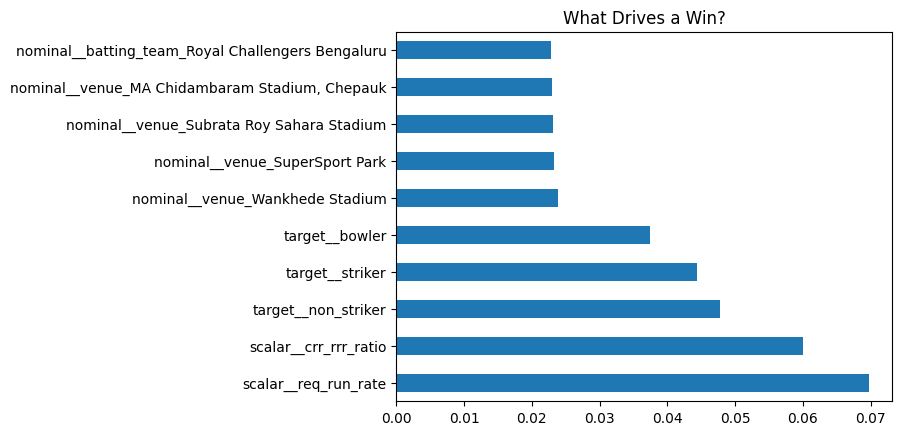

In [1400]:
import pandas as pd

xgb_model = best_estimator.named_steps['votingclassifier'].estimators_[2]
features = best_estimator.named_steps['columntransformer'].get_feature_names_out()

importance = pd.Series(xgb_model.feature_importances_, index=features).sort_values(ascending=False)
importance.head(10).plot(kind='barh', title='What Drives a Win?')

In [1401]:
from xgboost import XGBClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder,TargetEncoder,StandardScaler

overfit_cols = ['striker', 'non_striker', 'bowler', 'venue']

x_ttrain = x_train.drop(columns=overfit_cols)
x_ccv    = x_cv.drop(columns=overfit_cols)
x_ttest  = x_test.drop(columns=overfit_cols)

target_encode_modified = []

nominal_cols_modified = ['batting_team','bowling_team']

preprocessing_for_xgb = ColumnTransformer(transformers=[
    ('nominal', OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore'), nominal_cols_modified),
    ('target', TargetEncoder(cv=5), target_encode_modified),
    ('scalar', StandardScaler(), numeric_cols)
])

xgb_pipe = make_pipeline(
    preprocessing_for_xgb,
    XGBClassifier(
        n_estimators=100,
        max_depth=2,
        learning_rate=0.05,
        subsample=0.6,
        colsample_bytree=0.5,
        reg_lambda=20,
        reg_alpha=10,
        min_child_weight=50,
        gamma=5,
        eval_metric='logloss',
        random_state=42
    )
)

xgb_pipe.fit(x_ttrain, y_train)

print("Train:", accuracy_score(y_train, xgb_pipe.predict(x_ttrain)))
print("CV:   ", accuracy_score(y_cv,    xgb_pipe.predict(x_ccv)))
print("Test: ", accuracy_score(y_test,  xgb_pipe.predict(x_ttest)))

Train: 0.7409591194968553
CV:    0.7799774181407603
Test:  0.8238650773522699


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarn

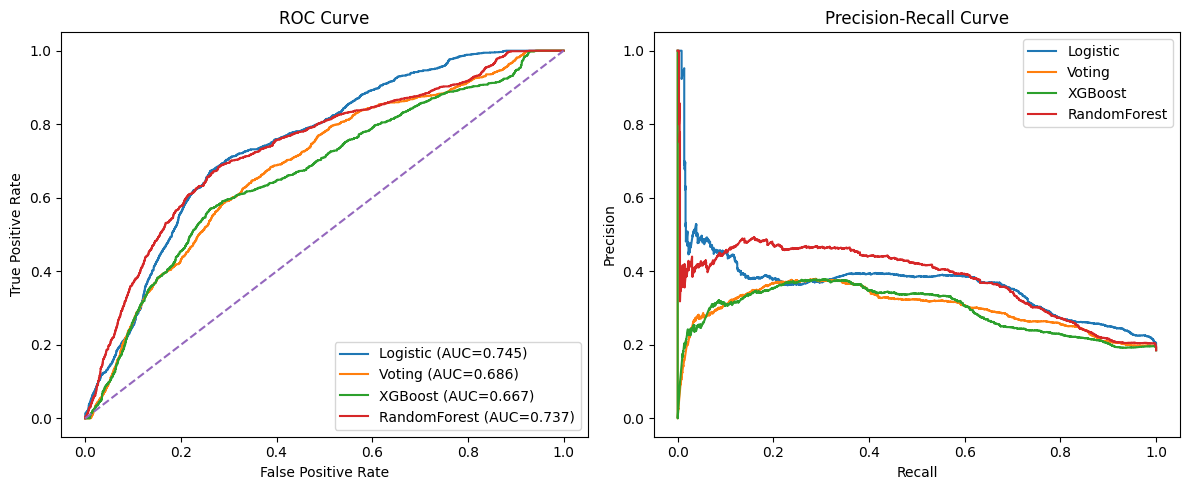


===== MODEL PERFORMANCE =====

Logistic
Accuracy : 0.7776
F1 Score : 0.3228
ROC AUC  : 0.7450

Voting
Accuracy : 0.7589
F1 Score : 0.3724
ROC AUC  : 0.6864

XGBoost
Accuracy : 0.7545
F1 Score : 0.3718
ROC AUC  : 0.6673

RandomForest
Accuracy : 0.8116
F1 Score : 0.0701
ROC AUC  : 0.7373


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


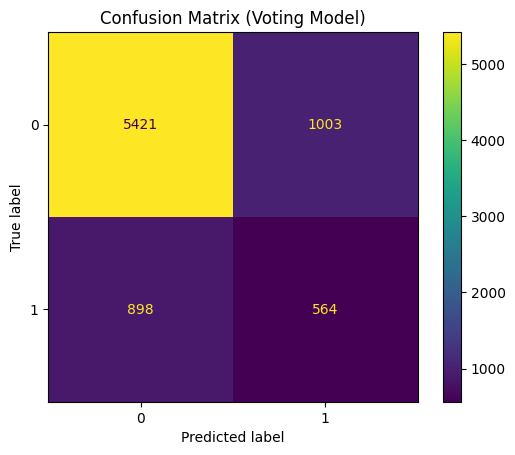

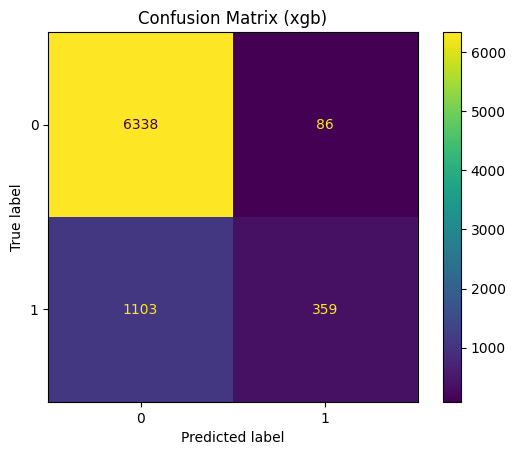

In [1405]:

import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve, auc,
    precision_recall_curve,
    accuracy_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)

models = {
    "Logistic": pipe,
    "Voting": best_estimator
}

models["XGBoost"] = best_estimator.named_steps['votingclassifier'].estimators_[2]
models["RandomForest"] = best_estimator.named_steps['votingclassifier'].estimators_[0]



results = {}

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

for name, model in models.items():

    if name in ["XGBoost", "RandomForest"]:
        X_test_transformed = best_estimator.named_steps['columntransformer'].transform(x_test)
        y_prob = model.predict_proba(X_test_transformed)[:, 1]
        y_pred = model.predict(X_test_transformed)
    else:
        y_prob = model.predict_proba(x_test)[:, 1]
        y_pred = model.predict(x_test)

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    results[name] = {
        "accuracy": accuracy_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc
    }

    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle='--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()


plt.subplot(1, 2, 2)

for name, model in models.items():

    if name in ["XGBoost", "RandomForest"]:
        X_test_transformed = best_estimator.named_steps['columntransformer'].transform(x_test)
        y_prob = model.predict_proba(X_test_transformed)[:, 1]
    else:
        y_prob = model.predict_proba(x_test)[:, 1]

    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    plt.plot(recall, precision, label=name)

plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()

plt.tight_layout()
plt.show()



print("\n===== MODEL PERFORMANCE =====")
for name, metrics in results.items():
    print(f"\n{name}")
    print(f"Accuracy : {metrics['accuracy']:.4f}")
    print(f"F1 Score : {metrics['f1']:.4f}")
    print(f"ROC AUC  : {metrics['roc_auc']:.4f}")



y_pred_voting = best_estimator.predict(x_test)

cm = confusion_matrix(y_test, y_pred_voting)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()
plt.title("Confusion Matrix (Voting Model)")
plt.show()

y_pred_xg = xgb_pipe.predict(x_ttest)

# Corrected line: Use y_pred_xg for the confusion matrix
cm = confusion_matrix(y_test, y_pred_xg)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()
plt.title("Confusion Matrix (xgb)")
plt.show()


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


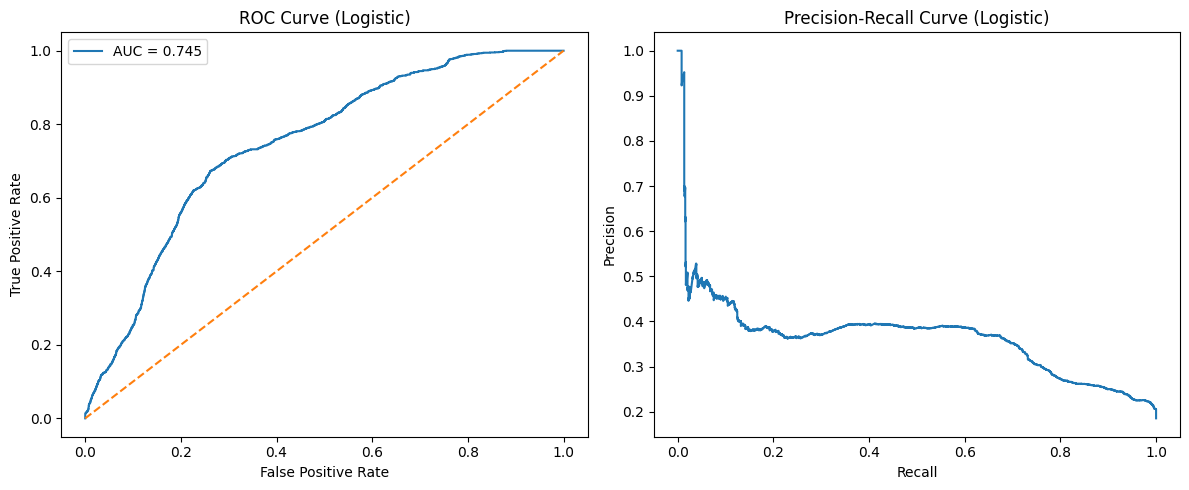

Best Threshold: 0.345
Accuracy: 0.7264
F1 Score: 0.4762
ROC AUC: 0.745


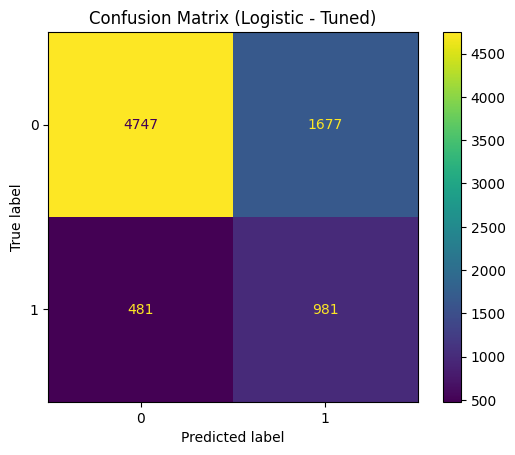

In [1408]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve, auc,
    precision_recall_curve,
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay
)

y_prob = pipe.predict_proba(x_test)[:, 1]


fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Logistic)")
plt.legend()


precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.subplot(1,2,2)
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Logistic)")

plt.tight_layout()
plt.show()


thresholds = np.linspace(0.1, 0.9, 50)
f1_scores = []

for t in thresholds:
    y_pred = (y_prob >= t).astype(int)
    f1_scores.append(f1_score(y_test, y_pred))

best_threshold = thresholds[np.argmax(f1_scores)]

y_pred_best = (y_prob >= best_threshold).astype(int)


print("Best Threshold:", round(best_threshold,3))
print("Accuracy:", round(accuracy_score(y_test, y_pred_best),4))
print("F1 Score:", round(f1_score(y_test, y_pred_best),4))
print("ROC AUC:", round(roc_auc_score(y_test, y_prob),4))


cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title("Confusion Matrix (Logistic - Tuned)")
plt.show()

In [1410]:
x_train.columns

Index(['venue', 'batting_team', 'bowling_team', 'striker', 'non_striker',
       'bowler', 'runs_to_win', 'curr_run_rate', 'req_run_rate',
       'crr_rrr_ratio', 'balls_remaining', 'wickets_remaining',
       'batting_average', 'career_strike_rate', 'exp_bowler_eco',
       'exp_bowler_avg'],
      dtype='object')

In [1412]:
import numpy as np
import pandas as pd

# =========================
# INPUT VALUES (YOU CHANGE THESE)
# =========================

venue = 'Eden Gardens Stadium'
batting_team = 'Kolkata Knight Riders'
bowling_team = 'Sunrisers Hyderabad'

striker = 'Rinku Singh'
non_striker = 'Raghuvanshi'
bowler = 'Malinga'

target = 227
team_runs = 120
balls_remaining = 55
wickets_remaining = 7

# Player stats (you must provide or fetch from your dataset)
batting_average = 28.5
career_strike_rate = 135.0
exp_bowler_eco = 7.8
exp_bowler_avg = 24.0

# =========================
# CALCULATIONS
# =========================

# Balls bowled
balls_bowled = 120 - balls_remaining

# Runs to win
runs_to_win = target - team_runs

# Current Run Rate
curr_run_rate = (team_runs * 6) / balls_bowled if balls_bowled > 0 else 0

# Required Run Rate
req_run_rate = (runs_to_win * 6) / balls_remaining if balls_remaining > 0 else 0
req_run_rate = min(req_run_rate, 36)

# Ratio
crr_rrr_ratio = curr_run_rate / req_run_rate if req_run_rate != 0 else 0
crr_rrr_ratio = min(crr_rrr_ratio, 10)

# =========================
# FINAL DATAFRAME ROW
# =========================

row = pd.DataFrame([{
    'venue': venue,
    'batting_team': batting_team,
    'bowling_team': bowling_team,
    'striker': striker,
    'non_striker': non_striker,
    'bowler': bowler,

    'runs_to_win': runs_to_win,
    'curr_run_rate': curr_run_rate,
    'req_run_rate': req_run_rate,
    'crr_rrr_ratio': crr_rrr_ratio,

    'balls_remaining': balls_remaining,
    'wickets_remaining': wickets_remaining,

    'batting_average': batting_average,
    'career_strike_rate': career_strike_rate,
    'exp_bowler_eco': exp_bowler_eco,
    'exp_bowler_avg': exp_bowler_avg
}])

print(row)

                  venue           batting_team         bowling_team  \
0  Eden Gardens Stadium  Kolkata Knight Riders  Sunrisers Hyderabad   

       striker  non_striker   bowler  runs_to_win  curr_run_rate  \
0  Rinku Singh  Raghuvanshi  Malinga          107      11.076923   

   req_run_rate  crr_rrr_ratio  balls_remaining  wickets_remaining  \
0     11.672727       0.948958               55                  7   

   batting_average  career_strike_rate  exp_bowler_eco  exp_bowler_avg  
0             28.5               135.0             7.8            24.0  


In [1413]:
import pandas as pd
import numpy as np

def create_input_row(df, venue, batting_team, bowling_team,
                     striker, non_striker, bowler,
                     target, team_runs, balls_remaining, wickets_remaining):

    # =========================
    # 1. VALIDATION (NO NEW VALUES)
    # =========================
    assert venue in df['venue'].values, "Venue not in dataset"
    assert batting_team in df['batting_team'].values, "Batting team not in dataset"
    assert bowling_team in df['bowling_team'].values, "Bowling team not in dataset"
    assert striker in df['striker'].values, "Striker not in dataset"
    assert non_striker in df['non_striker'].values, "Non-striker not in dataset"
    assert bowler in df['bowler'].values, "Bowler not in dataset"

    # =========================
    # 2. FETCH PLAYER STATS
    # =========================

    striker_stats = df[df['striker'] == striker].iloc[-1]
    bowler_stats = df[df['bowler'] == bowler].iloc[-1]

    batting_average = striker_stats['batting_average']
    career_strike_rate = striker_stats['career_strike_rate']

    exp_bowler_eco = bowler_stats['exp_bowler_eco']
    exp_bowler_avg = bowler_stats['exp_bowler_avg']

    # =========================
    # 3. CALCULATIONS
    # =========================

    balls_bowled = 120 - balls_remaining
    runs_to_win = target - team_runs

    curr_run_rate = (team_runs * 6) / balls_bowled if balls_bowled > 0 else 0

    req_run_rate = (runs_to_win * 6) / balls_remaining if balls_remaining > 0 else 0
    req_run_rate = min(req_run_rate, 36)

    crr_rrr_ratio = curr_run_rate / req_run_rate if req_run_rate != 0 else 0
    crr_rrr_ratio = min(crr_rrr_ratio, 10)

    # =========================
    # 4. FINAL ROW
    # =========================

    row = pd.DataFrame([{
        'venue': venue,
        'batting_team': batting_team,
        'bowling_team': bowling_team,
        'striker': striker,
        'non_striker': non_striker,
        'bowler': bowler,

        'runs_to_win': runs_to_win,
        'curr_run_rate': curr_run_rate,
        'req_run_rate': req_run_rate,
        'crr_rrr_ratio': crr_rrr_ratio,

        'balls_remaining': balls_remaining,
        'wickets_remaining': wickets_remaining,

        'batting_average': batting_average,
        'career_strike_rate': career_strike_rate,
        'exp_bowler_eco': exp_bowler_eco,
        'exp_bowler_avg': exp_bowler_avg
    }])

    return row

In [1423]:
def get_player_stats(df, player_name):

    if player_name in df['striker'].values:
        stats = df[df['striker'] == player_name].iloc[-1]
        return stats['batting_average'], stats['career_strike_rate']

    else:
        # fallback to average
        return df['batting_average'].mean(), df['career_strike_rate'].mean()


def get_bowler_stats(df, bowler_name):

    if bowler_name in df['bowler'].values:
        stats = df[df['bowler'] == bowler_name].iloc[-1]
        return stats['exp_bowler_eco'], stats['exp_bowler_avg']

    else:
        return df['exp_bowler_eco'].mean(), df['exp_bowler_avg'].mean()

In [1428]:
x_ttrain.columns

Index(['batting_team', 'bowling_team', 'runs_to_win', 'curr_run_rate',
       'req_run_rate', 'crr_rrr_ratio', 'balls_remaining', 'wickets_remaining',
       'batting_average', 'career_strike_rate', 'exp_bowler_eco',
       'exp_bowler_avg'],
      dtype='object')

In [1433]:
row = pd.DataFrame([{
    'batting_team': 'Kolkata Knight Riders',
    'bowling_team': 'Sunrisers Hyderabad',
    'runs_to_win': 107,
    'curr_run_rate': 11.08,
    'req_run_rate': 11.67,
    'crr_rrr_ratio': 0.95,
    'balls_remaining': 55,
    'wickets_remaining': 7,
    'batting_average': 27.0,
    'career_strike_rate': 135.0,
    'exp_bowler_eco': 7.5,
    'exp_bowler_avg': 25.0
}])


# prediction
print(xgb_pipe.predict(row))
print(xgb_pipe.predict_proba(row))

            batting_team         bowling_team  runs_to_win  curr_run_rate  \
0  Kolkata Knight Riders  Sunrisers Hyderabad          107          11.08   

   req_run_rate  crr_rrr_ratio  balls_remaining  wickets_remaining  \
0         11.67           0.95               55                  7   

   batting_average  career_strike_rate  exp_bowler_eco  exp_bowler_avg  
0             27.0               135.0             7.5            25.0  
[0]
[[0.73078954 0.26921043]]


In [1434]:
row = pd.DataFrame([{
    'batting_team': 'Mumbai Indians',
    'bowling_team': 'Chennai Super Kings',
    'runs_to_win': 48,
    'curr_run_rate': 8.5,
    'req_run_rate': 9.6,
    'crr_rrr_ratio': 0.88,
    'balls_remaining': 30,
    'wickets_remaining': 7,
    'batting_average': 28,
    'career_strike_rate': 140,
    'exp_bowler_eco': 7.2,
    'exp_bowler_avg': 26
}])
print(xgb_pipe.predict(row))
print(xgb_pipe.predict_proba(row))

[0]
[[0.85411054 0.14588946]]


In [1426]:
print("Unique Venues:", df['venue'].unique())
print("Unique Strikers:", df['striker'].unique())
print("Unique Non-Strikers:", df['non_striker'].unique())
print("Unique Bowlers:", df['bowler'].unique())

Unique Venues: ['M Chinnaswamy Stadium' 'Punjab Cricket Association Stadium, Mohali'
 'Feroz Shah Kotla' 'Eden Gardens' 'Sawai Mansingh Stadium'
 'Rajiv Gandhi International Stadium, Uppal'
 'MA Chidambaram Stadium, Chepauk' 'Dr DY Patil Sports Academy'
 'Wankhede Stadium' 'Newlands' "St George's Park" 'Kingsmead'
 'SuperSport Park' 'Buffalo Park' 'New Wanderers Stadium'
 'De Beers Diamond Oval' 'OUTsurance Oval' 'Brabourne Stadium'
 'Sardar Patel Stadium, Motera' 'Barabati Stadium'
 'Brabourne Stadium, Mumbai'
 'Vidarbha Cricket Association Stadium, Jamtha'
 'Himachal Pradesh Cricket Association Stadium' 'Nehru Stadium'
 'Holkar Cricket Stadium'
 'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium'
 'Subrata Roy Sahara Stadium' 'Maharashtra Cricket Association Stadium'
 'Shaheed Veer Narayan Singh International Stadium'
 'JSCA International Stadium Complex' 'Sheikh Zayed Stadium'
 'Sharjah Cricket Stadium' 'Dubai International Cricket Stadium'
 'Punjab Cricket Association IS Bindra S

In [1420]:
df['striker'].unique()

array(['R Dravid', 'W Jaffer', 'V Kohli', 'JH Kallis', 'CL White',
       'MV Boucher', 'B Akhil', 'AA Noffke', 'P Kumar', 'Z Khan',
       'SB Joshi', 'K Goel', 'JR Hopes', 'KC Sangakkara', 'Yuvraj Singh',
       'SM Katich', 'IK Pathan', 'G Gambhir', 'V Sehwag', 'S Dhawan',
       'WP Saha', 'BB McCullum', 'RT Ponting', 'SC Ganguly', 'DJ Hussey',
       'Mohammad Hafeez', 'LR Shukla', 'M Kaif', 'YK Pathan',
       'Kamran Akmal', 'SR Watson', 'DS Lehmann', 'RA Jadeja', 'L Ronchi',
       'ST Jayasuriya', 'RV Uthappa', 'SM Pollock', 'DJ Bravo',
       'AM Nayar', 'MA Khote', 'Harbhajan Singh', 'A Nehra', 'GC Smith',
       'SK Warne', 'D Salunkhe', 'Pankaj Singh', 'SS Tiwary',
       'DS Kulkarni', 'PA Patel', 'ML Hayden', 'MS Dhoni',
       'DPMD Jayawardene', 'TM Srivastava', 'B Lee', 'B Chipli',
       'LRPL Taylor', 'DW Steyn', 'Salman Butt', 'AB Agarkar', 'BJ Hodge',
       'DB Das', 'Umar Gul', 'AB Dinda', 'I Sharma', 'AB de Villiers',
       'AC Gilchrist', 'VVS Laxman', 'HH Gi